# Quantitative Trading With Machine Learning

## Project Overview

This project investigates whether machine learning can predict the short-term future returns of Volkswagen AG's American Depositary Receipt (VWAGY) using historical market information and information from related supply-chain and industry companies.

The target is VWAGY, and the dataset is constructed using daily Yahoo Finance market data. The enhanced feature set contains 276 features: 24 VWAGY technical features and 252 lagged return features derived from nine publicly traded supply-chain or industry proxy companies. For each proxy company, returns from the previous 28 trading days are used as features.

The prediction task is formulated as a regression problem. Future VWAGY returns are predicted at six horizons: 1, 5, 10, 15, 20, and 25 trading days.

Four machine learning regression models are evaluated:

- Elastic Net
- Decision Tree
- XGBoost
- LightGBM

To avoid data leakage, the experiment uses chronological paper-style rolling evaluation rather than random splitting. Each rolling window consists of five years of training data, one year of validation data, and one month of unseen test data. The window moves forward by one month and the training period expands as more historical observations become available. Model and forecast-horizon selection are performed using validation data, while the test periods are used only for out-of-sample evaluation.

The main evaluation metrics are RMSE, MAE, R², and prediction correlation. The predictions are also converted into simple trading signals using different return thresholds and compared with a VWAGY Buy-and-Hold benchmark.

The purpose of this project is not to assume that machine learning will necessarily produce profitable trades, but to empirically test whether the available historical and supply-chain information provides a stable out-of-sample predictive signal for VWAGY returns.

QUANTITATIVE TRADING WITH MACHINE LEARNING
PAPER-METHODOLOGY IMPLEMENTATION

Target: VWAGY
Proxy companies: CON.DE, IFX.DE, HLE.DE, BAS.DE, BWA, MGA, LEA, APTV, TSM

VWAGY rows: 2766
VWAGY: 2015-01-02 to 2025-12-31

  OK: 2795 rows
  OK: 2795 rows
  OK: 2795 rows
  OK: 2795 rows
  OK: 2766 rows
  OK: 2766 rows
  OK: 2766 rows
  OK: 2766 rows
  OK: 2766 rows

Supplier matrix: (2840, 9)

FEATURE ENGINEERING
VWAGY technical features: 24
Supply-chain features: 252
Total features: 276
✓ Correct 276-feature dataset

Final dataset: (2681, 282)
Features: 276
Date range: 2015-03-31 to 2025-11-24

PAPER-STYLE ROLLING WINDOWS
Number of windows: 56

First window:
TRAIN: 2015-03-31 -> 2020-03-31
VALIDATION: 2020-03-31 -> 2021-03-31
TEST: 2021-03-31 -> 2021-04-30

WINDOW 1/56
Selected model: XGBoost
Selected horizon: 1 days
Validation RMSE: 0.036630
Test RMSE: 0.030302
Test MAE: 0.026912
Test R²: -1.1504

WINDOW 2/56
Selected model: XGBoost
Selected horizon: 1 days
Validation RMSE: 0.034478
Test RMS

,Horizon,Mean_RMSE,Mean_MAE,Mean_R2,Windows
0,1,0.021307,0.016695,-0.14441,56


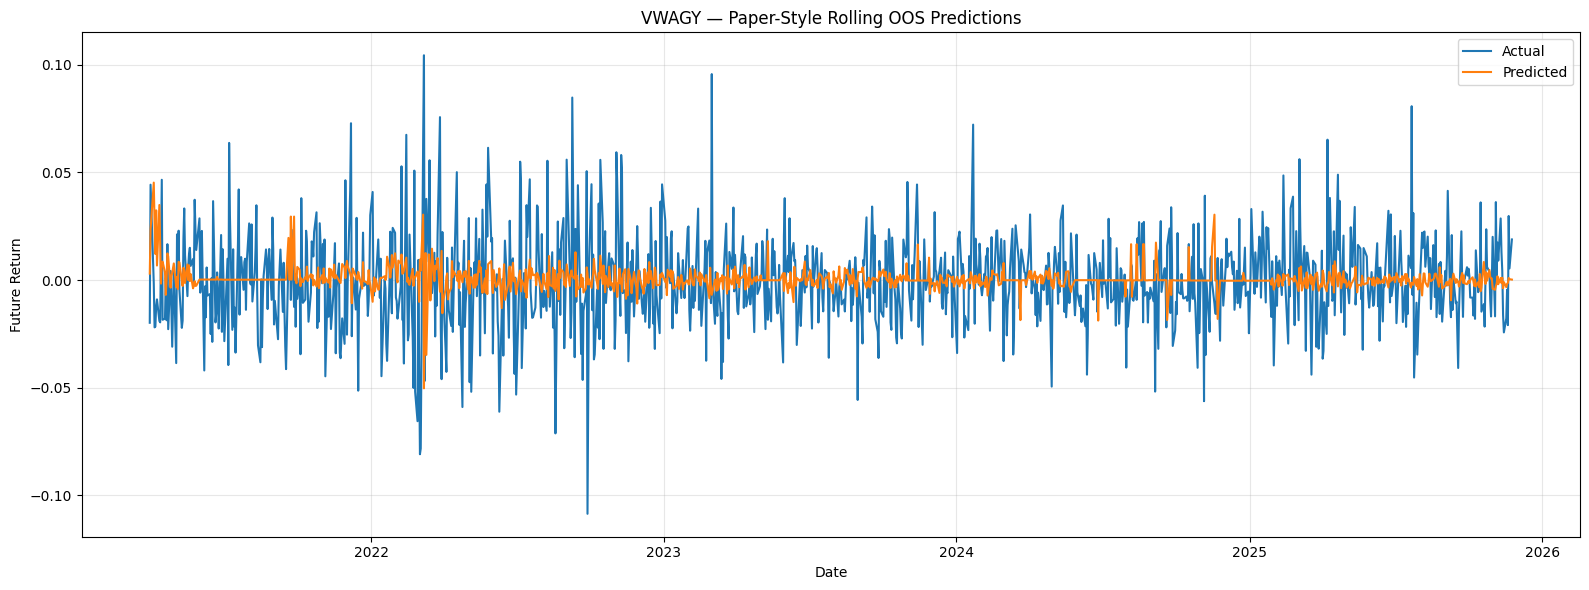

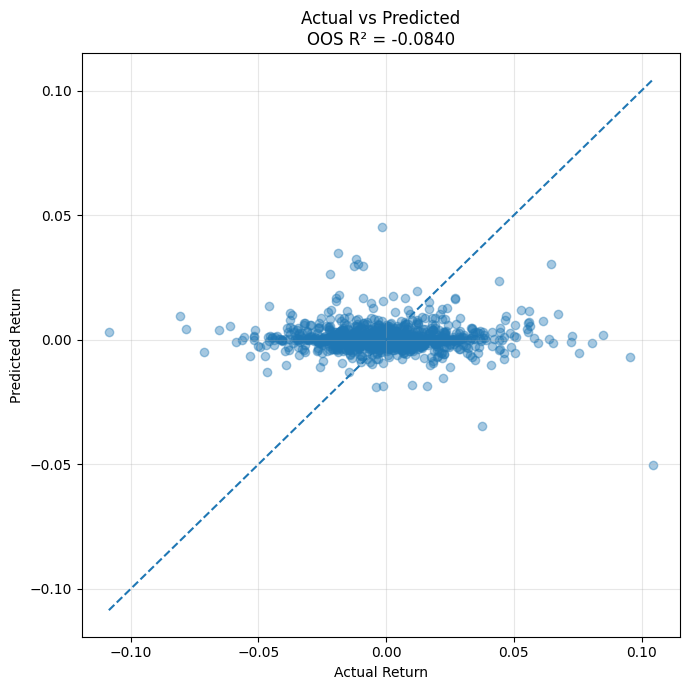


PAPER-STYLE TRADING RESULTS


,Threshold,Total_Return,Annualized_Return,Annualized_Volatility,Sharpe,Max_Drawdown,Trades
0,0.0000,-0.792677,-0.287448,0.343656,-0.836441,-0.837887,489
1,0.0025,-0.706314,-0.231949,0.343866,-0.674531,-0.832452,220
2,0.0050,-0.861349,-0.346593,0.342870,-1.010861,-0.896818,83
3,0.0100,-0.230034,-0.054748,0.343645,-0.159315,-0.497933,20



Buy & Hold
Total Return : -57.81%
Annual Return: -16.96%
Volatility   : 34.40%
Sharpe       : -0.4931
Max Drawdown : -69.80%

BEST PAPER-STYLE STRATEGY
Threshold : 1.00%
Return    : -23.00%
Sharpe    : -0.1593
Trades    : 20

EUR 1 PER TRADE SENSITIVITY


,Threshold,Total_Return_After_1EUR_Cost,Sharpe,Max_Drawdown,Trades
0,0.0000,-1.228337,NaN,-1.232634,489
1,0.0025,-0.931267,-1.274477,-0.938392,220
2,0.0050,-0.905624,-1.162391,-0.926476,83
3,0.0100,-0.250434,-0.175178,-0.502292,20


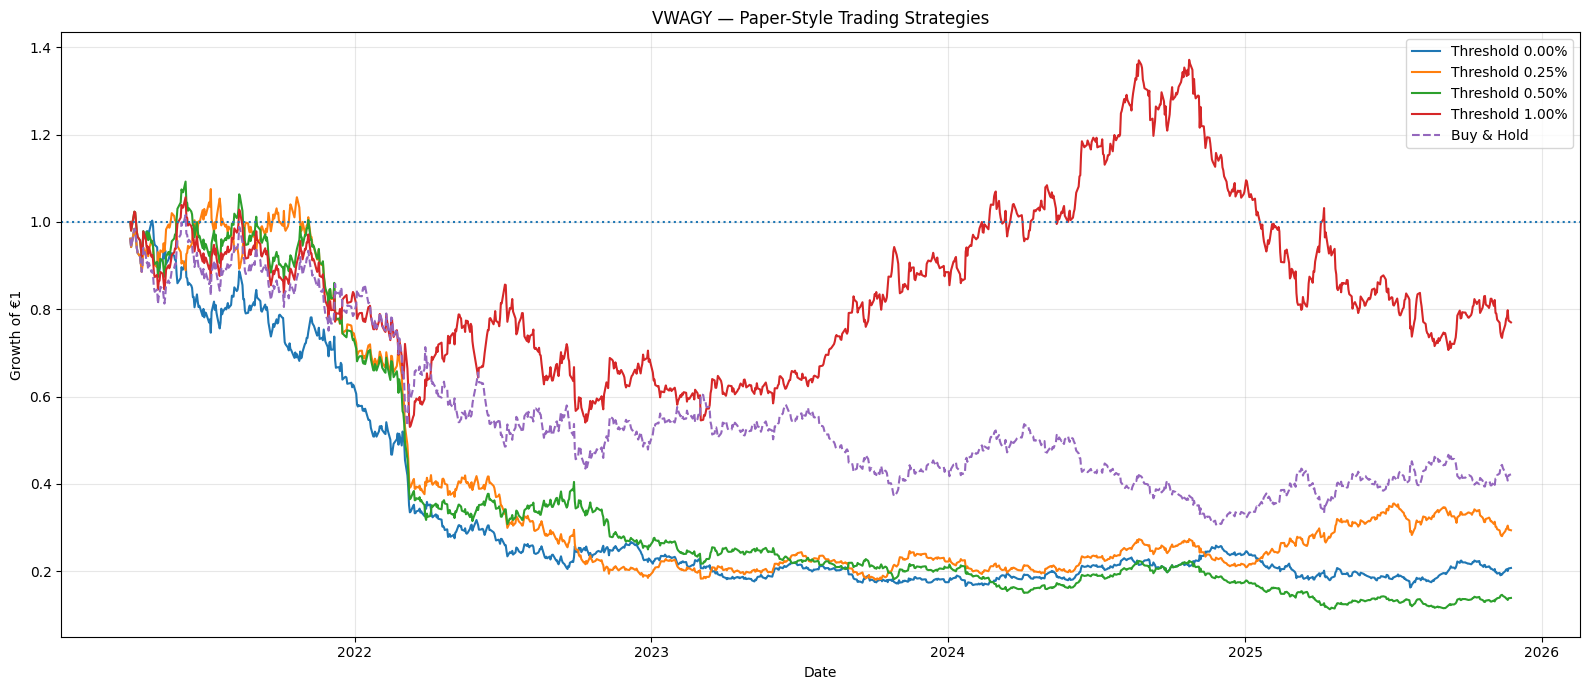


FINAL PROJECT SUMMARY

Dataset
-------
Target                  : VWAGY

Period                  : 2015-03-31
                          to
                          2025-11-24

Features                : 276

VWAGY technical         : 24
Supply-chain            : 252

Models
------
Elastic Net
Decision Tree
XGBoost
LightGBM

Horizons
--------
1D
5D
10D
15D
20D
25D

Paper-Style Evaluation
----------------------
Initial training        : 5 years
Validation              : 1 year
Test                    : 1 month
Rolling frequency       : 1 month
Training window         : Expanding

Aggregate OOS Results
---------------------
RMSE                    : 0.022532
MAE                     : 0.016674
R²                      : -0.084046
Correlation             : -0.052283

Buy & Hold
----------
Total Return            : -57.81%
Sharpe                  : -0.4931
Max Drawdown             : -69.80%


⚠ Aggregate OOS R² is negative.
This means the tested feature/model configuration did not outperform 

In [11]:
# ============================================================
# QUANTITATIVE TRADING WITH MACHINE LEARNING
# PAPER-METHODOLOGY VERSION
#
# DATASET:
#   Our existing dataset / feature universe
#
# METHODOLOGY:
#   Based on Stanford CS229 "Quantitative Trading with
#   Machine Learning"
#
# DATA:
#   VWAGY + 9 supply-chain/industry proxy companies
#
# FEATURES:
#   24 VWAGY technical features
#   252 supply-chain lag features
#   = 276 total features
#
# MODELS:
#   Elastic Net
#   Decision Tree
#   XGBoost
#   LightGBM
#
# HORIZONS:
#   1, 5, 10, 15, 20, 25 days
#
# ROLLING METHODOLOGY:
#   Initial:
#       5 years training
#       1 year validation
#       1 month test
#
#   Then:
#       validation/test windows roll forward by 1 month
#       previous test month becomes historical data
#
# EVALUATION:
#   RMSE
#   MAE
#   R2
#   Correlation
#
# TRADING:
#   Starting capital = EUR 1000
#   Thresholds = 0%, 0.25%, 0.5%, 1%
#   Long / Short
#   Paper-style trade accounting
#
# IMPORTANT:
#   This is a scaled-down implementation of the paper.
#   We retain OUR dataset instead of the paper's original
#   supplier universe and proprietary macro variables.
# ============================================================


# ============================================================
# 1. INSTALL PACKAGES IF REQUIRED
# ============================================================

# Uncomment in Google Colab if necessary:
#
# !pip install yfinance xgboost lightgbm -q


# ============================================================
# 2. IMPORTS
# ============================================================

import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import yfinance as yf

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import ElasticNet
from sklearn.tree import DecisionTreeRegressor

from sklearn.metrics import (
    mean_squared_error,
    mean_absolute_error,
    r2_score
)

from xgboost import XGBRegressor
from lightgbm import LGBMRegressor


# ============================================================
# 3. CONFIGURATION
# ============================================================

TARGET_TICKER = "VWAGY"

START_DATE = "2015-01-01"
END_DATE = "2026-01-01"

RANDOM_STATE = 42

# Paper uses six horizons
HORIZONS = [
    1,
    5,
    10,
    15,
    20,
    25
]

MODEL_NAMES = [
    "Elastic Net",
    "Decision Tree",
    "XGBoost",
    "LightGBM"
]

# Rolling methodology
TRAIN_YEARS = 5
VALIDATION_YEARS = 1
TEST_MONTHS = 1
ROLL_MONTHS = 1

# Trading
INITIAL_CAPITAL = 1000.0

THRESHOLDS = [
    0.00,
    0.0025,
    0.0050,
    0.0100
]

# Paper discussion uses 1 EUR per transaction
TRANSACTION_COST_EUR = 1.0


# ============================================================
# 4. OUR SUPPLY-CHAIN / INDUSTRY PROXY DATASET
# ============================================================

SUPPLY_CHAIN_TICKERS = [
    "CON.DE",
    "IFX.DE",
    "HLE.DE",
    "BAS.DE",
    "BWA",
    "MGA",
    "LEA",
    "APTV",
    "TSM"
]


print("=" * 80)
print("QUANTITATIVE TRADING WITH MACHINE LEARNING")
print("PAPER-METHODOLOGY IMPLEMENTATION")
print("=" * 80)

print("\nTarget:", TARGET_TICKER)

print(
    "Proxy companies:",
    ", ".join(SUPPLY_CHAIN_TICKERS)
)


# ============================================================
# 5. DOWNLOAD VWAGY
# ============================================================

print("\nDownloading VWAGY...")

vw = yf.download(
    TARGET_TICKER,
    start=START_DATE,
    end=END_DATE,
    auto_adjust=True,
    progress=False
)


if isinstance(
    vw.columns,
    pd.MultiIndex
):

    vw.columns = (
        vw.columns
        .get_level_values(0)
    )


vw = vw[
    [
        "Open",
        "High",
        "Low",
        "Close",
        "Volume"
    ]
].copy()


vw.index = pd.to_datetime(
    vw.index
)

vw = vw.sort_index()


print(
    "VWAGY rows:",
    len(vw)
)

print(
    "VWAGY:",
    vw.index.min().date(),
    "to",
    vw.index.max().date()
)


# ============================================================
# 6. DOWNLOAD PROXY DATA
# ============================================================

supplier_data = {}

print(
    "\nDownloading proxy companies..."
)


for ticker in SUPPLY_CHAIN_TICKERS:

    print(
        f"Downloading {ticker}..."
    )

    try:

        temp = yf.download(
            ticker,
            start=START_DATE,
            end=END_DATE,
            auto_adjust=True,
            progress=False
        )

        if isinstance(
            temp.columns,
            pd.MultiIndex
        ):

            temp.columns = (
                temp.columns
                .get_level_values(0)
            )


        if "Close" not in temp.columns:

            print(
                f"  WARNING: Close unavailable"
            )

            continue


        supplier_data[ticker] = (
            temp["Close"]
            .rename(ticker)
        )


        print(
            f"  OK: {len(temp)} rows"
        )


    except Exception as e:

        print(
            f"  ERROR: {e}"
        )


# ============================================================
# 7. COMBINE PROXY PRICES
# ============================================================

supplier_prices = pd.concat(
    supplier_data.values(),
    axis=1
)


supplier_prices = (
    supplier_prices
    .sort_index()
    .ffill(limit=5)
)


print(
    "\nSupplier matrix:",
    supplier_prices.shape
)


# ============================================================
# 8. FEATURE ENGINEERING
#
# OUR DATASET:
#   24 VWAGY technical features
#   252 proxy lag features
#   276 total
# ============================================================

feature_data = pd.DataFrame(
    index=vw.index
)


close = vw["Close"]


# ------------------------------------------------------------
# 24 VWAGY TECHNICAL FEATURES
# ------------------------------------------------------------

windows = [
    3,
    5,
    10,
    20,
    30,
    60
]


daily_returns = (
    close
    .pct_change()
)


for window in windows:

    # Return
    feature_data[
        f"Return_{window}D"
    ] = (
        close
        .pct_change(window)
    )


    # Volatility
    feature_data[
        f"Volatility_{window}D"
    ] = (
        daily_returns
        .rolling(window)
        .std()
    )


    # Absolute return
    feature_data[
        f"Abs_Return_{window}D"
    ] = (
        close
        .pct_change(window)
        .abs()
    )


    # Momentum
    feature_data[
        f"Momentum_{window}D"
    ] = (
        close / close.shift(window)
        - 1
    )


# ------------------------------------------------------------
# 252 SUPPLY-CHAIN FEATURES
#
# 9 proxies × 28 return lags
# ------------------------------------------------------------

supplier_returns = (
    supplier_prices
    .pct_change()
)


SUPPLIER_LAGS = 28


for ticker in SUPPLY_CHAIN_TICKERS:

    if ticker not in supplier_returns.columns:

        continue


    for lag in range(
        1,
        SUPPLIER_LAGS + 1
    ):

        feature_data[
            f"{ticker}_Return_Lag{lag}"
        ] = (
            supplier_returns[ticker]
            .shift(lag)
        )


# ============================================================
# 9. FEATURE COUNT
# ============================================================

EXPECTED_FEATURES = 276


print(
    "\n" + "=" * 80
)

print(
    "FEATURE ENGINEERING"
)

print(
    "=" * 80
)

print(
    "VWAGY technical features:",
    24
)

print(
    "Supply-chain features:",
    252
)

print(
    "Total features:",
    feature_data.shape[1]
)


if feature_data.shape[1] == EXPECTED_FEATURES:

    print(
        "✓ Correct 276-feature dataset"
    )

else:

    print(
        "⚠ WARNING:"
    )

    print(
        "Expected:",
        EXPECTED_FEATURES,
        "Found:",
        feature_data.shape[1]
    )


# ============================================================
# 10. CREATE ALL SIX PAPER TARGETS
# ============================================================

data = feature_data.copy()


for horizon in HORIZONS:

    data[
        f"Target_{horizon}D"
    ] = (
        close.shift(-horizon)
        / close
        - 1
    )


feature_columns = (
    feature_data.columns.tolist()
)


target_columns = [
    f"Target_{h}D"
    for h in HORIZONS
]


# Complete cases
data = data.dropna(
    subset=
    feature_columns +
    target_columns
)


X = data[
    feature_columns
].copy()


print(
    "\nFinal dataset:",
    data.shape
)

print(
    "Features:",
    X.shape[1]
)

print(
    "Date range:",
    X.index.min().date(),
    "to",
    X.index.max().date()
)


# ============================================================
# 11. MODEL FACTORY
#
# These are the same model families used in the paper.
#
# Hyperparameters are practical fixed settings for this
# scaled-down implementation. The paper itself performs
# hyperparameter selection, but does not provide a complete
# reproducible grid for every model in the paper text.
# ============================================================

def create_model(model_name):

    if model_name == "Elastic Net":

        return Pipeline(
            [
                (
                    "scaler",
                    StandardScaler()
                ),

                (
                    "model",
                    ElasticNet(
                        alpha=0.001,
                        l1_ratio=0.5,
                        max_iter=10000,
                        random_state=RANDOM_STATE
                    )
                )
            ]
        )


    elif model_name == "Decision Tree":

        return DecisionTreeRegressor(
            max_depth=5,
            min_samples_split=10,
            min_samples_leaf=20,
            random_state=RANDOM_STATE
        )


    elif model_name == "XGBoost":

        return XGBRegressor(
            n_estimators=300,
            max_depth=4,
            learning_rate=0.03,
            subsample=0.8,
            colsample_bytree=0.8,
            objective="reg:squarederror",
            random_state=RANDOM_STATE,
            n_jobs=-1
        )


    elif model_name == "LightGBM":

        return LGBMRegressor(
            n_estimators=300,
            learning_rate=0.03,
            max_depth=4,
            num_leaves=20,
            subsample=0.8,
            colsample_bytree=0.8,
            random_state=RANDOM_STATE,
            verbosity=-1,
            n_jobs=-1
        )


    raise ValueError(
        f"Unknown model: {model_name}"
    )


# ============================================================
# 12. PAPER-STYLE ROLLING WINDOWS
#
# IMPORTANT:
#
# Initial:
#
#   5Y TRAIN
#   1Y VALIDATION
#   1M TEST
#
# Then the window moves forward one month.
#
# The historical training period EXPANDS.
#
# Example:
#
# Window 1
# TRAIN: 2015 -> 2020
# VALID: 2020 -> 2021
# TEST : April 2021
#
# Window 2
# TRAIN: 2015 -> April 2020
# VALID: April 2020 -> April 2021
# TEST : May 2021
#
# This matches the paper's rolling/expanding structure.
# ============================================================

dates = pd.DatetimeIndex(
    X.index
)


first_date = dates.min()


initial_validation_start = (
    first_date
    + pd.DateOffset(
        years=TRAIN_YEARS
    )
)


initial_test_start = (
    initial_validation_start
    + pd.DateOffset(
        years=VALIDATION_YEARS
    )
)


# Keep training origin fixed.
# Training period expands as validation/test roll forward.

train_origin = first_date


rolling_windows = []


test_start = initial_test_start


while test_start < dates.max():

    validation_start = (
        test_start
        - pd.DateOffset(
            years=VALIDATION_YEARS
        )
    )


    test_end = (
        test_start
        + pd.DateOffset(
            months=TEST_MONTHS
        )
    )


    train_mask = (
        (X.index >= train_origin)
        &
        (X.index < validation_start)
    )


    validation_mask = (
        (X.index >= validation_start)
        &
        (X.index < test_start)
    )


    test_mask = (
        (X.index >= test_start)
        &
        (X.index < test_end)
    )


    if (
        train_mask.sum() > 200
        and
        validation_mask.sum() > 100
        and
        test_mask.sum() > 0
    ):

        rolling_windows.append(
            {
                "train_start":
                    train_origin,

                "train_end":
                    validation_start,

                "validation_start":
                    validation_start,

                "validation_end":
                    test_start,

                "test_start":
                    test_start,

                "test_end":
                    test_end,

                "train_mask":
                    train_mask,

                "validation_mask":
                    validation_mask,

                "test_mask":
                    test_mask
            }
        )


    test_start = (
        test_start
        + pd.DateOffset(
            months=ROLL_MONTHS
        )
    )


print(
    "\n" + "=" * 80
)

print(
    "PAPER-STYLE ROLLING WINDOWS"
)

print(
    "=" * 80
)

print(
    "Number of windows:",
    len(rolling_windows)
)


if rolling_windows:

    w = rolling_windows[0]

    print(
        "\nFirst window:"
    )

    print(
        "TRAIN:",
        w["train_start"].date(),
        "->",
        w["train_end"].date()
    )

    print(
        "VALIDATION:",
        w["validation_start"].date(),
        "->",
        w["validation_end"].date()
    )

    print(
        "TEST:",
        w["test_start"].date(),
        "->",
        w["test_end"].date()
    )


# ============================================================
# 13. STORAGE
# ============================================================

oos_predictions = []

window_metrics = []

model_selection = []


# ============================================================
# 14. ROLLING PAPER EXPERIMENT
# ============================================================

for window_number, window in enumerate(
    rolling_windows,
    start=1
):

    print(
        "\n" + "=" * 80
    )

    print(
        f"WINDOW "
        f"{window_number}/{len(rolling_windows)}"
    )

    print(
        "=" * 80
    )


    train_idx = X.index[
        window["train_mask"]
    ]


    validation_idx = X.index[
        window["validation_mask"]
    ]


    test_idx = X.index[
        window["test_mask"]
    ]


    X_train = X.loc[
        train_idx
    ]


    X_validation = X.loc[
        validation_idx
    ]


    X_test = X.loc[
        test_idx
    ]


    # --------------------------------------------------------
    # MODEL / HORIZON HORSE RACE
    # --------------------------------------------------------

    validation_results = []


    for horizon in HORIZONS:

        target = (
            f"Target_{horizon}D"
        )


        y_train = data.loc[
            train_idx,
            target
        ]


        y_validation = data.loc[
            validation_idx,
            target
        ]


        for model_name in MODEL_NAMES:

            model = create_model(
                model_name
            )


            # Fit ONLY on training
            model.fit(
                X_train,
                y_train
            )


            validation_pred = (
                model.predict(
                    X_validation
                )
            )


            validation_rmse = np.sqrt(
                mean_squared_error(
                    y_validation,
                    validation_pred
                )
            )


            validation_mae = (
                mean_absolute_error(
                    y_validation,
                    validation_pred
                )
            )


            validation_r2 = (
                r2_score(
                    y_validation,
                    validation_pred
                )
            )


            validation_results.append(
                {
                    "Model":
                        model_name,

                    "Horizon":
                        horizon,

                    "RMSE":
                        validation_rmse,

                    "MAE":
                        validation_mae,

                    "R2":
                        validation_r2
                }
            )


    validation_df = pd.DataFrame(
        validation_results
    )


    # --------------------------------------------------------
    # PAPER SELECTION CRITERION:
    #
    # LOWEST VALIDATION RMSE
    # --------------------------------------------------------

    best = (
        validation_df
        .sort_values(
            "RMSE"
        )
        .iloc[0]
    )


    best_model = (
        best["Model"]
    )


    best_horizon = int(
        best["Horizon"]
    )


    print(
        "Selected model:",
        best_model
    )

    print(
        "Selected horizon:",
        best_horizon,
        "days"
    )

    print(
        "Validation RMSE:",
        f"{best['RMSE']:.6f}"
    )


    model_selection.append(
        {
            "Window":
                window_number,

            "Test_Start":
                window["test_start"],

            "Model":
                best_model,

            "Horizon":
                best_horizon,

            "Validation_RMSE":
                best["RMSE"],

            "Validation_MAE":
                best["MAE"],

            "Validation_R2":
                best["R2"]
        }
    )


    # --------------------------------------------------------
    # RETRAIN ON TRAIN + VALIDATION
    # --------------------------------------------------------

    train_validation_idx = (
        train_idx
        .append(
            validation_idx
        )
    )


    X_train_validation = X.loc[
        train_validation_idx
    ]


    y_train_validation = data.loc[
        train_validation_idx,
        f"Target_{best_horizon}D"
    ]


    final_model = create_model(
        best_model
    )


    final_model.fit(
        X_train_validation,
        y_train_validation
    )


    # --------------------------------------------------------
    # FINAL UNSEEN TEST
    # --------------------------------------------------------

    y_test = data.loc[
        test_idx,
        f"Target_{best_horizon}D"
    ]


    test_pred = (
        final_model.predict(
            X_test
        )
    )


    # --------------------------------------------------------
    # METRICS
    # --------------------------------------------------------

    test_rmse = np.sqrt(
        mean_squared_error(
            y_test,
            test_pred
        )
    )


    test_mae = (
        mean_absolute_error(
            y_test,
            test_pred
        )
    )


    test_r2 = (
        r2_score(
            y_test,
            test_pred
        )
    )


    if (
        y_test.std() > 0
        and
        np.std(test_pred) > 0
    ):

        correlation = np.corrcoef(
            y_test,
            test_pred
        )[0, 1]

    else:

        correlation = np.nan


    print(
        "Test RMSE:",
        f"{test_rmse:.6f}"
    )

    print(
        "Test MAE:",
        f"{test_mae:.6f}"
    )

    print(
        "Test R²:",
        f"{test_r2:.4f}"
    )


    window_metrics.append(
        {
            "Window":
                window_number,

            "Test_Start":
                test_idx.min(),

            "Test_End":
                test_idx.max(),

            "Model":
                best_model,

            "Horizon":
                best_horizon,

            "Test_RMSE":
                test_rmse,

            "Test_MAE":
                test_mae,

            "Test_R2":
                test_r2,

            "Correlation":
                correlation
        }
    )


    # --------------------------------------------------------
    # SAVE OOS PREDICTIONS
    # --------------------------------------------------------

    temp_predictions = pd.DataFrame(
        {
            "Date":
                test_idx,

            "Actual":
                y_test.values,

            "Predicted":
                test_pred,

            "Model":
                best_model,

            "Horizon":
                best_horizon,

            "Window":
                window_number
        }
    )


    oos_predictions.append(
        temp_predictions
    )


# ============================================================
# 15. COMBINE OOS RESULTS
# ============================================================

oos_df = pd.concat(
    oos_predictions,
    ignore_index=True
)


oos_df = (
    oos_df
    .sort_values(
        "Date"
    )
    .drop_duplicates(
        "Date"
    )
    .reset_index(
        drop=True
    )
)


# ============================================================
# 16. AGGREGATE OOS METRICS
# ============================================================

overall_rmse = np.sqrt(
    mean_squared_error(
        oos_df["Actual"],
        oos_df["Predicted"]
    )
)


overall_mae = (
    mean_absolute_error(
        oos_df["Actual"],
        oos_df["Predicted"]
    )
)


overall_r2 = (
    r2_score(
        oos_df["Actual"],
        oos_df["Predicted"]
    )
)


overall_correlation = np.corrcoef(
    oos_df["Actual"],
    oos_df["Predicted"]
)[0, 1]


# ============================================================
# 17. FINAL PREDICTION RESULTS
# ============================================================

print(
    "\n" + "=" * 80
)

print(
    "FINAL PAPER-STYLE OOS RESULTS"
)

print(
    "=" * 80
)

print(
    f"Rolling windows : "
    f"{len(window_metrics)}"
)

print(
    f"OOS observations : "
    f"{len(oos_df)}"
)

print(
    f"\nRMSE : "
    f"{overall_rmse:.6f}"
)

print(
    f"MAE  : "
    f"{overall_mae:.6f}"
)

print(
    f"R²   : "
    f"{overall_r2:.6f}"
)

print(
    f"Corr : "
    f"{overall_correlation:.6f}"
)


# ============================================================
# 18. WINDOW RESULTS
# ============================================================

window_results_df = pd.DataFrame(
    window_metrics
)


selection_df = pd.DataFrame(
    model_selection
)


print(
    "\n" + "=" * 80
)

print(
    "MODEL SELECTION FREQUENCY"
)

print(
    "=" * 80
)

print(
    selection_df[
        "Model"
    ].value_counts()
)


print(
    "\nHORIZON SELECTION FREQUENCY"
)

print(
    selection_df[
        "Horizon"
    ].value_counts()
)


# ============================================================
# 19. MODEL PERFORMANCE BY HORIZON
# ============================================================
#
# This lets us see whether the paper's observation that
# error increases with forecast horizon also appears in
# OUR dataset.
# ============================================================

print(
    "\n" + "=" * 80
)

print(
    "OOS PERFORMANCE BY HORIZON"
)

print(
    "=" * 80
)


horizon_summary = (
    window_results_df
    .groupby("Horizon")
    .agg(
        Mean_RMSE=(
            "Test_RMSE",
            "mean"
        ),

        Mean_MAE=(
            "Test_MAE",
            "mean"
        ),

        Mean_R2=(
            "Test_R2",
            "mean"
        ),

        Windows=(
            "Window",
            "count"
        )
    )
    .reset_index()
)


display(
    horizon_summary
)


# ============================================================
# 20. ACTUAL VS PREDICTED
# ============================================================

plt.figure(
    figsize=(16, 6)
)

plt.plot(
    oos_df["Date"],
    oos_df["Actual"],
    label="Actual"
)

plt.plot(
    oos_df["Date"],
    oos_df["Predicted"],
    label="Predicted"
)

plt.title(
    "VWAGY — Paper-Style Rolling OOS Predictions"
)

plt.xlabel(
    "Date"
)

plt.ylabel(
    "Future Return"
)

plt.legend()

plt.grid(
    True,
    alpha=0.3
)

plt.tight_layout()

plt.show()


# ============================================================
# 21. ACTUAL VS PREDICTED SCATTER
# ============================================================

plt.figure(
    figsize=(7, 7)
)

plt.scatter(
    oos_df["Actual"],
    oos_df["Predicted"],
    alpha=0.4
)


minimum = min(
    oos_df["Actual"].min(),
    oos_df["Predicted"].min()
)


maximum = max(
    oos_df["Actual"].max(),
    oos_df["Predicted"].max()
)


plt.plot(
    [minimum, maximum],
    [minimum, maximum],
    linestyle="--"
)


plt.xlabel(
    "Actual Return"
)

plt.ylabel(
    "Predicted Return"
)

plt.title(
    f"Actual vs Predicted\n"
    f"OOS R² = {overall_r2:.4f}"
)

plt.grid(
    True,
    alpha=0.3
)

plt.tight_layout()

plt.show()


# ============================================================
# 22. PAPER-STYLE TRADING STRATEGY
# ============================================================
#
# Paper:
#
# Starting bankroll = EUR 1000
#
# If predicted return > threshold:
#       LONG
#
# If predicted return < -threshold:
#       SHORT
#
# Otherwise:
#       HOLD CURRENT POSITION
#
# The paper evaluates thresholds:
#
#       0%
#       0.25%
#       0.50%
#       1%
#
# We evaluate every threshold for every selected
# rolling model/horizon.
#
# IMPORTANT:
# The prediction horizon determines the return being
# predicted, but the position is updated using each
# new OOS prediction.
# ============================================================


# ------------------------------------------------------------
# Get actual daily VWAGY returns
# ------------------------------------------------------------

daily_vw_returns = (
    close
    .pct_change()
)


# Align with OOS predictions

trading_base = oos_df.copy()


trading_base[
    "Daily_Return"
] = (
    daily_vw_returns
    .reindex(
        trading_base["Date"]
    )
    .values
)


trading_base = (
    trading_base
    .dropna(
        subset=[
            "Daily_Return"
        ]
    )
)


# ============================================================
# 23. BACKTEST FUNCTION
# ============================================================

def run_paper_strategy(
    predictions,
    threshold,
    transaction_cost=0.0,
    initial_capital=1000.0
):

    df = (
        predictions
        .copy()
        .sort_values(
            "Date"
        )
        .reset_index(
            drop=True
        )
    )


    capital = (
        initial_capital
    )


    position = 0

    trades = 0

    equity_values = []

    positions = []


    for i in range(
        len(df)
    ):

        predicted = (
            df.loc[
                i,
                "Predicted"
            ]
        )


        actual_return = (
            df.loc[
                i,
                "Daily_Return"
            ]
        )


        # ----------------------------------------------------
        # Generate signal
        # ----------------------------------------------------

        if predicted > threshold:

            desired_position = 1


        elif predicted < -threshold:

            desired_position = -1


        else:

            desired_position = position


        # ----------------------------------------------------
        # Trade if position changes
        # ----------------------------------------------------

        if (
            desired_position
            !=
            position
        ):

            trades += 1

            capital -= (
                transaction_cost
            )

            position = (
                desired_position
            )


        # ----------------------------------------------------
        # Daily portfolio return
        # ----------------------------------------------------

        capital *= (
            1
            +
            position
            *
            actual_return
        )


        positions.append(
            position
        )


        equity_values.append(
            capital
        )


    df[
        "Position"
    ] = positions


    df[
        "Equity"
    ] = equity_values


    total_return = (
        capital /
        initial_capital
        - 1
    )


    daily_strategy_returns = (
        df["Position"]
        *
        df["Daily_Return"]
    )


    if (
        len(
            daily_strategy_returns
        ) > 1
    ):

        annualized_return = (
            (1 + total_return)
            **
            (
                252 /
                len(df)
            )
            - 1
        )


        annualized_volatility = (
            daily_strategy_returns.std()
            *
            np.sqrt(252)
        )


    else:

        annualized_return = np.nan

        annualized_volatility = np.nan


    if (
        annualized_volatility
        and
        annualized_volatility > 0
    ):

        sharpe = (
            annualized_return
            /
            annualized_volatility
        )

    else:

        sharpe = np.nan


    running_max = (
        df["Equity"]
        .cummax()
    )


    drawdown = (
        df["Equity"]
        /
        running_max
        - 1
    )


    max_drawdown = (
        drawdown.min()
    )


    return {
        "Threshold":
            threshold,

        "Final_Capital":
            capital,

        "Total_Return":
            total_return,

        "Annualized_Return":
            annualized_return,

        "Annualized_Volatility":
            annualized_volatility,

        "Sharpe":
            sharpe,

        "Max_Drawdown":
            max_drawdown,

        "Trades":
            trades,

        "Equity":
            df["Equity"]
    }


# ============================================================
# 24. RUN ALL PAPER THRESHOLDS
# ============================================================

strategy_results = []


strategy_equities = {}


for threshold in THRESHOLDS:

    result = run_paper_strategy(
        trading_base,
        threshold=threshold,
        transaction_cost=0.0,
        initial_capital=INITIAL_CAPITAL
    )


    strategy_results.append(
        {
            "Threshold":
                threshold,

            "Total_Return":
                result["Total_Return"],

            "Annualized_Return":
                result["Annualized_Return"],

            "Annualized_Volatility":
                result["Annualized_Volatility"],

            "Sharpe":
                result["Sharpe"],

            "Max_Drawdown":
                result["Max_Drawdown"],

            "Trades":
                result["Trades"]
        }
    )


    strategy_equities[
        threshold
    ] = result["Equity"]


strategy_results_df = pd.DataFrame(
    strategy_results
)


# ============================================================
# 25. BUY & HOLD
# ============================================================

buy_hold_equity = (
    1 +
    trading_base[
        "Daily_Return"
    ]
).cumprod()


buy_hold_total_return = (
    buy_hold_equity.iloc[-1]
    - 1
)


buy_hold_daily_returns = (
    trading_base[
        "Daily_Return"
    ]
)


buy_hold_annualized_return = (
    (1 + buy_hold_total_return)
    **
    (
        252 /
        len(trading_base)
    )
    - 1
)


buy_hold_volatility = (
    buy_hold_daily_returns.std()
    *
    np.sqrt(252)
)


buy_hold_sharpe = (
    buy_hold_annualized_return
    /
    buy_hold_volatility
)


buy_hold_running_max = (
    buy_hold_equity
    .cummax()
)


buy_hold_drawdown = (
    buy_hold_equity
    /
    buy_hold_running_max
    - 1
)


buy_hold_max_drawdown = (
    buy_hold_drawdown.min()
)


# ============================================================
# 26. PAPER TRADING RESULTS
# ============================================================

print(
    "\n" + "=" * 80
)

print(
    "PAPER-STYLE TRADING RESULTS"
)

print(
    "=" * 80
)


display(
    strategy_results_df
)


print(
    "\nBuy & Hold"
)

print(
    f"Total Return : "
    f"{buy_hold_total_return:.2%}"
)

print(
    f"Annual Return: "
    f"{buy_hold_annualized_return:.2%}"
)

print(
    f"Volatility   : "
    f"{buy_hold_volatility:.2%}"
)

print(
    f"Sharpe       : "
    f"{buy_hold_sharpe:.4f}"
)

print(
    f"Max Drawdown : "
    f"{buy_hold_max_drawdown:.2%}"
)


# ============================================================
# 27. BEST PAPER-STYLE STRATEGY
# ============================================================

best_strategy = (
    strategy_results_df
    .sort_values(
        "Total_Return",
        ascending=False
    )
    .iloc[0]
)


print(
    "\n" + "=" * 80
)

print(
    "BEST PAPER-STYLE STRATEGY"
)

print(
    "=" * 80
)

print(
    f"Threshold : "
    f"{best_strategy['Threshold']:.2%}"
)

print(
    f"Return    : "
    f"{best_strategy['Total_Return']:.2%}"
)

print(
    f"Sharpe    : "
    f"{best_strategy['Sharpe']:.4f}"
)

print(
    f"Trades    : "
    f"{int(best_strategy['Trades'])}"
)


# ============================================================
# 28. TRANSACTION COST SENSITIVITY
# ============================================================
#
# The paper itself abstracts from transaction costs in its
# main strategy calculation, but discusses the impact of
# approximately EUR 1 per trade.
#
# We therefore report both:
#
#   A. No transaction cost
#   B. EUR 1 per trade
# ============================================================

cost_results = []


for threshold in THRESHOLDS:

    result = run_paper_strategy(
        trading_base,
        threshold=threshold,
        transaction_cost=
            TRANSACTION_COST_EUR,
        initial_capital=
            INITIAL_CAPITAL
    )


    cost_results.append(
        {
            "Threshold":
                threshold,

            "Total_Return_After_1EUR_Cost":
                result["Total_Return"],

            "Sharpe":
                result["Sharpe"],

            "Max_Drawdown":
                result["Max_Drawdown"],

            "Trades":
                result["Trades"]
        }
    )


cost_results_df = pd.DataFrame(
    cost_results
)


print(
    "\n" + "=" * 80
)

print(
    "EUR 1 PER TRADE SENSITIVITY"
)

print(
    "=" * 80
)

display(
    cost_results_df
)


# ============================================================
# 29. EQUITY CURVE
# ============================================================

plt.figure(
    figsize=(16, 7)
)


for threshold in THRESHOLDS:

    equity = (
        strategy_equities[
            threshold
        ]
        /
        INITIAL_CAPITAL
    )


    plt.plot(
        trading_base["Date"],
        equity,
        label=
        f"Threshold {threshold:.2%}"
    )


plt.plot(
    trading_base["Date"],
    buy_hold_equity,
    label="Buy & Hold",
    linestyle="--"
)


plt.axhline(
    1,
    linestyle=":"
)


plt.title(
    "VWAGY — Paper-Style Trading Strategies"
)

plt.xlabel(
    "Date"
)

plt.ylabel(
    "Growth of €1"
)

plt.legend()

plt.grid(
    True,
    alpha=0.3
)

plt.tight_layout()

plt.show()


# ============================================================
# 30. SAVE RESULTS
# ============================================================

oos_df.to_csv(
    "paper_style_oos_predictions.csv",
    index=False
)


window_results_df.to_csv(
    "paper_style_window_results.csv",
    index=False
)


selection_df.to_csv(
    "paper_style_model_selection.csv",
    index=False
)


horizon_summary.to_csv(
    "paper_style_horizon_summary.csv",
    index=False
)


strategy_results_df.to_csv(
    "paper_style_trading_results.csv",
    index=False
)


cost_results_df.to_csv(
    "paper_style_transaction_cost_results.csv",
    index=False
)


# ============================================================
# 31. FINAL SUMMARY
# ============================================================

print(
    "\n" + "=" * 80
)

print(
    "FINAL PROJECT SUMMARY"
)

print(
    "=" * 80
)

print(
    f"""
Dataset
-------
Target                  : VWAGY

Period                  : {X.index.min().date()}
                          to
                          {X.index.max().date()}

Features                : {X.shape[1]}

VWAGY technical         : 24
Supply-chain            : 252

Models
------
Elastic Net
Decision Tree
XGBoost
LightGBM

Horizons
--------
1D
5D
10D
15D
20D
25D

Paper-Style Evaluation
----------------------
Initial training        : 5 years
Validation              : 1 year
Test                    : 1 month
Rolling frequency       : 1 month
Training window         : Expanding

Aggregate OOS Results
---------------------
RMSE                    : {overall_rmse:.6f}
MAE                     : {overall_mae:.6f}
R²                      : {overall_r2:.6f}
Correlation             : {overall_correlation:.6f}

Buy & Hold
----------
Total Return            : {buy_hold_total_return:.2%}
Sharpe                  : {buy_hold_sharpe:.4f}
Max Drawdown             : {buy_hold_max_drawdown:.2%}
"""
)


# ============================================================
# 32. INTERPRETATION
# ============================================================

if overall_r2 > 0:

    print(
        "\n✓ Positive aggregate OOS R²."
    )

    print(
        "The model explains some variation in "
        "future VWAGY returns beyond the mean baseline."
    )

else:

    print(
        "\n⚠ Aggregate OOS R² is negative."
    )

    print(
        "This means the tested feature/model "
        "configuration did not outperform the "
        "mean-return baseline on the full OOS period."
    )


print(
    "\n✓ Paper-style experiment completed."
)

# Conclusion

The final paper-style rolling experiment evaluated 276 features using four machine learning regression models across six forecast horizons. The evaluation used an expanding time-series methodology with five years of initial training data, one year of validation data, and one month of out-of-sample testing, repeated monthly.

The aggregate out-of-sample results were:

- **RMSE:** 0.022532
- **MAE:** 0.016674
- **R²:** -0.084046
- **Correlation:** -0.052283

The negative aggregate R² means that the model predictions did not outperform the simple mean-return baseline across the complete out-of-sample period. This does not mean that the implementation failed or that machine learning cannot be applied to financial prediction. Several individual rolling windows produced positive R² values, showing that useful predictive relationships appeared during some market regimes. However, these relationships were not stable enough to remain effective across the entire evaluation period.

The predictions were also concentrated relatively close to zero, while actual VWAGY returns showed considerably larger positive and negative movements. This indicates that the models struggled to capture the magnitude of short-term market movements.

A major reason for the limited performance is that this project is a scaled-down public-data implementation. It uses nine supply-chain and industry proxies rather than a complete Volkswagen supplier network and does not include the broader macroeconomic information used in the reference methodology. Financial returns are also inherently noisy and relationships between companies can change across market regimes.

The Buy-and-Hold benchmark also experienced a substantial decline over the evaluated period, with a total return of approximately **-57.81%**, a Sharpe ratio of **-0.4931**, and a maximum drawdown of **-69.80%**.

Overall, the experiment demonstrates a complete leakage-aware quantitative trading pipeline, but the tested feature set and models did not produce a stable predictive signal across the full out-of-sample period. The negative result is therefore an important empirical finding rather than evidence of a failed implementation. It highlights the difficulty of predicting short-term financial returns and the importance of evaluating machine learning strategies using strict out-of-sample time-series testing.